## Discrete-time state-space neural networks: a special recurrent network architecture


While neural ordinary differential equations (NODEs) describe systems' dynamics in the continuous-time domain and therefore require numerical ODE integration, one can also use an ANN to describe the right-hand side of a **discrete-time state-space model**:
$$\begin{align}
\hat{x}[k+1] &= f_w(\hat{x}[k],\, u[k]), \quad x[0]=x_0, \\
\hat{y}[k]   &= g_w(\hat{x}[k],\, u[k]).
\end{align}$$
Here $f_w(\cdot)$ and $g_w(\cdot)$ are ANN-based representations of the true system dynamics. With an equidistant time grid (sampling index $k$, interval $\Delta t$), this lets us model discrete-time system behavior via a **difference equation** — no ODE solver required.



### Thermal behavior of a DC-motor

We re-use the [DC-motor temperature example](Hammerstein_Temperature_Motor.ipynb) with the Hammerstein ground-truth model:
$$\frac{\mathrm{d}}{\mathrm{d}t}x(t) = \frac{1}{C_\mathrm{Th}}\left(\frac{\vartheta_\mathrm{A}(t)-x(t)}{R_\mathrm{Th}} + P_\mathrm{v}(u(t), x(t))\right).$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn


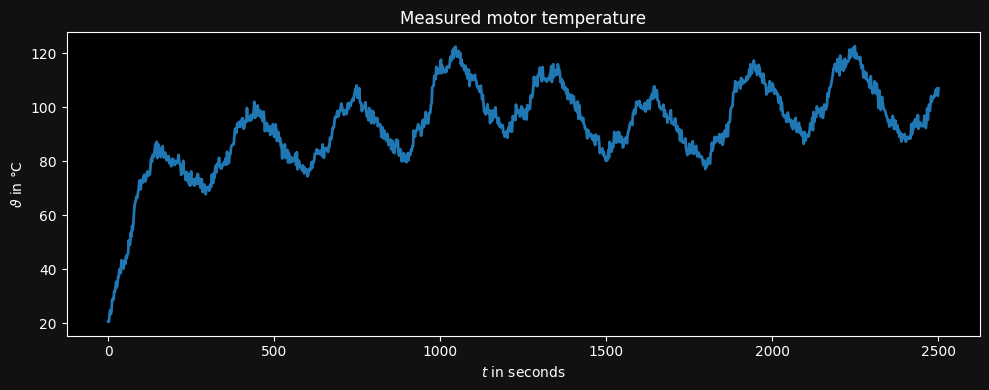

In [3]:
# True input signals
i_signal = lambda t: 125 + 50*np.sin(2*np.pi*t/60)   + 60*np.sin(2*np.pi*t/300)
n_signal = lambda t: 1000 + 100*np.cos(2*np.pi*t/100) + 500*np.cos(2*np.pi*t/1000)
ϑ_A      = lambda t: 20   + 2*np.sin(2*np.pi*t/2000)

# True motor parameters
R_Cu0, α_Cu = 0.016,  0.0039
R_Fe0, α_Fe = 5000.0, 0.00651
L            = 0.05
C_Th         = 1400.0
R_Th         = 0.17

def motor_ode(t, x):
    theta = x[0]
    R_Cu = R_Cu0 * (1 + α_Cu * (theta - 20))
    R_Fe = R_Fe0 * (1 + α_Fe * (theta - 20))
    Pv   = i_signal(t)**2 * R_Cu + (L * i_signal(t) * n_signal(t) / 60 * 2*np.pi)**2 / R_Fe
    return [(1/C_Th) * ((-theta + ϑ_A(t)) / R_Th + Pv)]

x0    = [20.0]
dt    = 2.0
t_end = 2500.0
tsteps = np.arange(0.0, t_end + dt, dt, dtype=np.float32)

sol    = solve_ivp(motor_ode, (0.0, t_end), x0, method='RK45', t_eval=tsteps, max_step=dt)
x_true = sol.y[0]

np.random.seed(42)
y = (x_true + 1.5 * np.random.randn(len(x_true))).astype(np.float32)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tsteps, y, lw=2)
ax.set(title="Measured motor temperature",
       xlabel=r"$t$ in seconds", ylabel=r"$\vartheta$ in °C")
ax.set_facecolor("#000000"); fig.patch.set_facecolor("#111111")
for obj in [ax.title, ax.xaxis.label, ax.yaxis.label]: obj.set_color("white")
ax.tick_params(colors="white")
[s.set_edgecolor("white") for s in ax.spines.values()]
plt.tight_layout(); plt.show()


### Discrete-time black-box style modeling approach


We use a black-box difference-equation model with **no structural priors**:
$$\hat{x}[k+1] = \hat{x}[k] + f_w(\hat{x}[k],\; i[k],\; n[k],\; \vartheta_\mathrm{A}[k]), \quad x[0]=x_0.$$
Inputs are the raw motor current $i[k]$, speed $n[k]$, ambient temperature $\vartheta_\mathrm{A}[k]$, and the current state estimate $\hat{x}[k]$. Since the motor temperature is directly measured (up to noise), we do not need a separate output equation $g_w(\cdot)$.


Configure the training time grid and standardise all signals (critical for black-box models):

In [4]:
datasize    = int(t_end / dt + 1)
tsteps_NODE = np.linspace(0.0, t_end, datasize, dtype=np.float32)

# Raw input features over the training grid
i_vec   = np.array([i_signal(t_) for t_ in tsteps_NODE], dtype=np.float32)
n_vec   = np.array([n_signal(t_) for t_ in tsteps_NODE], dtype=np.float32)
ϑ_A_vec = np.array([ϑ_A(t_)      for t_ in tsteps_NODE], dtype=np.float32)

# Z-score standardisation — fit on training data
sc_i   = StandardScaler().fit(i_vec  .reshape(-1,1))
sc_n   = StandardScaler().fit(n_vec  .reshape(-1,1))
sc_ϑ_A = StandardScaler().fit(ϑ_A_vec.reshape(-1,1))
sc_y   = StandardScaler().fit(y      .reshape(-1,1))

i_norm   = sc_i  .transform(i_vec  .reshape(-1,1)).ravel().astype(np.float32)
n_norm   = sc_n  .transform(n_vec  .reshape(-1,1)).ravel().astype(np.float32)
ϑ_A_norm = sc_ϑ_A.transform(ϑ_A_vec.reshape(-1,1)).ravel().astype(np.float32)
y_norm   = sc_y  .transform(y      .reshape(-1,1)).ravel().astype(np.float32)

y_mean  = float(sc_y.mean_[0])
y_scale = float(sc_y.scale_[0])
print(f"y_mean = {y_mean:.3f} °C  |  y_scale = {y_scale:.4f}")


y_mean = 93.239 °C  |  y_scale = 15.7009



We build a small 2-layer ANN with `tanh` output activation — this allows the model to predict both positive and negative normalised temperature increments $\Delta\hat{x}[k]$ between time steps. The `gain=0.05` initialisation keeps increments small at the start of training, preventing divergence.


In [6]:
def small_glorot_init(module, gain=0.05):
    """Xavier/Glorot uniform init scaled down by `gain` to keep early increments small."""
    if isinstance(module, nn.Linear):
        nn.init.xavier_uniform_(module.weight, gain=gain)
        nn.init.zeros_(module.bias)

torch.manual_seed(140588)

ann_DE = nn.Sequential(
    nn.Linear(4, 10), nn.Tanh(),   # inputs: [i_norm, n_norm, ϑ_A_norm, x_norm]
    nn.Linear(10, 1), nn.Tanh(),   # output: normalised temperature increment Δx
)
ann_DE.apply(small_glorot_init)


Sequential(
  (0): Linear(in_features=4, out_features=10, bias=True)
  (1): Tanh()
  (2): Linear(in_features=10, out_features=1, bias=True)
  (3): Tanh()
)

Define a differentiable rollout loss and a prediction helper:

In [ ]:
# Pre-convert to tensors (done once)
i_t   = torch.tensor(i_norm)
n_t   = torch.tensor(n_norm)
ϑ_A_t = torch.tensor(ϑ_A_norm)
y_t   = torch.tensor(y_norm)

def rollout(ann, feat1, feat2, feat3, y0_norm):
    """
    calculate x on a recursive fashion, using the ANN to predict the increment at each step and feeding it back in for the next step.
    Differentiable one-step rollout of the difference-equation model.
    Inputs feat1/feat2/feat3 are normalised feature tensors of length T.
    Returns predicted normalised temperature trajectory of length T.
    """
    x = y0_norm                  # scalar tensor (normalised)
    preds = [x]
    T = len(y_t)
    for k in range(T - 1):
        inp = torch.stack([feat1[k], feat2[k], feat3[k], x])  # (4,)
        dx  = ann(inp.unsqueeze(0))[0, 0]
        x   = x + dx
        preds.append(x)
    return torch.stack(preds)   # (T,)

def loss_DE(feat1, feat2, feat3):
    pred = rollout(ann_DE, feat1, feat2, feat3, y_t[0])
    return torch.sum((y_t - pred) ** 2)

@torch.no_grad()
def predict_DE(feat1, feat2, feat3):
    """Return temperature predictions in original °C scale."""
    pred_norm = rollout(ann_DE, feat1, feat2, feat3, y_t[0]).numpy()
    return pred_norm * y_scale + y_mean


Solve the optimisation problem (Adam, 1 000 iterations):

In [8]:
optimizer = torch.optim.Adam(ann_DE.parameters(), lr=0.01)
losses_raw = []

print("Training black-box model (raw features: i, n, ϑ_A)...")
for it in range(1, 1001):
    optimizer.zero_grad()
    loss = loss_DE(i_t, n_t, ϑ_A_t)
    loss.backward()
    optimizer.step()
    losses_raw.append(float(loss))
    if it % 50 == 0:
        print(f"  iter {it:4d}  |  loss = {loss.item():.4f}")

print("Done.")


Training black-box model (raw features: i, n, ϑ_A)...


C:\Users\27abd\AppData\Local\Temp\ipykernel_22064\1856859294.py:10: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  losses_raw.append(float(loss))


  iter   50  |  loss = 71.3462
  iter  100  |  loss = 24.5397
  iter  150  |  loss = 23.5333
  iter  200  |  loss = 22.9876
  iter  250  |  loss = 22.5121
  iter  300  |  loss = 22.0664
  iter  350  |  loss = 23.3858
  iter  400  |  loss = 21.1575
  iter  450  |  loss = 20.5951
  iter  500  |  loss = 19.9576
  iter  550  |  loss = 19.5413
  iter  600  |  loss = 19.6630
  iter  650  |  loss = 18.1560
  iter  700  |  loss = 18.1121
  iter  750  |  loss = 18.1732
  iter  800  |  loss = 23.5676
  iter  850  |  loss = 16.0815
  iter  900  |  loss = 15.9188
  iter  950  |  loss = 15.6169
  iter 1000  |  loss = 14.6916
Done.


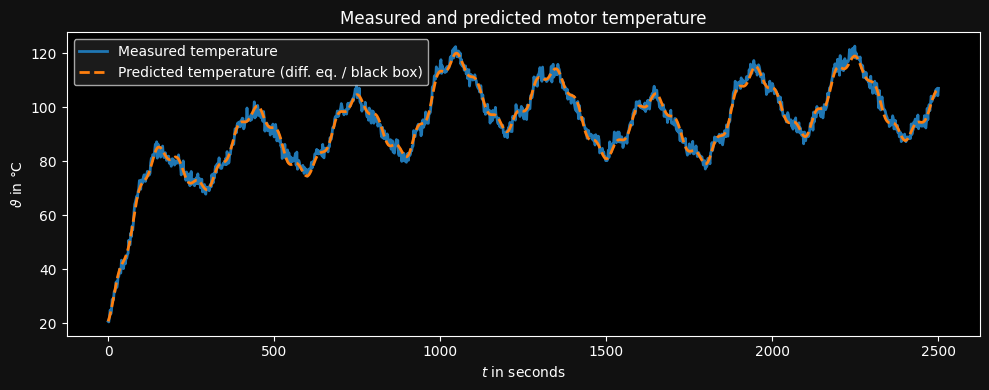

In [9]:
pred_raw = predict_DE(i_t, n_t, ϑ_A_t)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tsteps_NODE, y,       lw=2, label="Measured temperature")
ax.plot(tsteps_NODE, pred_raw, lw=2, linestyle='--',
        label="Predicted temperature (diff. eq. / black box)")
ax.set(title="Measured and predicted motor temperature",
       xlabel=r"$t$ in seconds", ylabel=r"$\vartheta$ in °C")
ax.legend(loc="upper left", facecolor="#222222", labelcolor="white")
ax.set_facecolor("#000000"); fig.patch.set_facecolor("#111111")
for obj in [ax.title, ax.xaxis.label, ax.yaxis.label]: obj.set_color("white")
ax.tick_params(colors="white")
[s.set_edgecolor("white") for s in ax.spines.values()]
plt.tight_layout(); plt.show()


### Adding some expert features


Although the previous black-box model delivered decent results, we can improve accuracy by injecting minimal a priori knowledge — **without changing the model's structural form**. Instead of the raw signals $\{i[k], n[k]\}$, we use the physics-motivated features:
$$\left\{i^2[k],\quad (i[k]\cdot n[k])^2\right\}$$
which are closely related to the motor's copper and iron power losses respectively. This is a lightweight form of feature engineering that bridges black-box and grey-box thinking.


Compute and standardise the new expert features:

In [10]:
i_sqr_vec  = np.array([i_signal(t_)**2                for t_ in tsteps_NODE], dtype=np.float32)
in_sqr_vec = np.array([(i_signal(t_)*n_signal(t_))**2 for t_ in tsteps_NODE], dtype=np.float32)

# Fit new scalers (on training data only)
sc_i_sqr  = StandardScaler().fit(i_sqr_vec .reshape(-1,1))
sc_in_sqr = StandardScaler().fit(in_sqr_vec.reshape(-1,1))

i_sqr_norm  = sc_i_sqr .transform(i_sqr_vec .reshape(-1,1)).ravel().astype(np.float32)
in_sqr_norm = sc_in_sqr.transform(in_sqr_vec.reshape(-1,1)).ravel().astype(np.float32)

i_sqr_t  = torch.tensor(i_sqr_norm)
in_sqr_t = torch.tensor(in_sqr_norm)

print(f"i²  :  mean={i_sqr_vec.mean():.1f}  std={i_sqr_vec.std():.1f}")
print(f"(in)²: mean={in_sqr_vec.mean():.1f}  std={in_sqr_vec.std():.1f}")


i²  :  mean=19199.3  std=14366.8
(in)²: mean=21956730880.0  std=24392728576.0



We reformulate the optimisation problem using the expert feature vector $\{i^2[k],\;(i\cdot n)^2[k],\;\vartheta_\mathrm{A}[k],\;\hat{x}[k]\}$ and re-initialise the ANN weights from scratch so the comparison with the raw-feature model is fair.


In [11]:
# Fresh ANN with identical architecture — re-initialised for a fair comparison
torch.manual_seed(140588)

ann_DE_expert = nn.Sequential(
    nn.Linear(4, 10), nn.Tanh(),   # inputs: [i²_norm, (in)²_norm, ϑ_A_norm, x_norm]
    nn.Linear(10, 1), nn.Tanh(),
)
ann_DE_expert.apply(small_glorot_init)

def loss_DE_expert():
    pred = rollout(ann_DE_expert, i_sqr_t, in_sqr_t, ϑ_A_t, y_t[0])
    return torch.sum((y_t - pred) ** 2)

@torch.no_grad()
def predict_DE_expert():
    pred_norm = rollout(ann_DE_expert, i_sqr_t, in_sqr_t, ϑ_A_t, y_t[0]).numpy()
    return pred_norm * y_scale + y_mean

optimizer_expert = torch.optim.Adam(ann_DE_expert.parameters(), lr=0.01)
losses_expert = []

print("Training black-box model (expert features: i², (i·n)², ϑ_A)...")
for it in range(1, 1001):
    optimizer_expert.zero_grad()
    loss = loss_DE_expert()
    loss.backward()
    optimizer_expert.step()
    losses_expert.append(float(loss))
    if it % 50 == 0:
        print(f"  iter {it:4d}  |  loss = {loss.item():.4f}")

print("Done.")


Training black-box model (expert features: i², (i·n)², ϑ_A)...
  iter   50  |  loss = 81.7541
  iter  100  |  loss = 14.0257
  iter  150  |  loss = 13.2106
  iter  200  |  loss = 12.8203
  iter  250  |  loss = 12.4983
  iter  300  |  loss = 12.2339
  iter  350  |  loss = 12.0172
  iter  400  |  loss = 11.8405
  iter  450  |  loss = 11.6993
  iter  500  |  loss = 11.5910
  iter  550  |  loss = 11.5130
  iter  600  |  loss = 11.4608
  iter  650  |  loss = 12.0726
  iter  700  |  loss = 11.4259
  iter  750  |  loss = 11.4007
  iter  800  |  loss = 11.3870
  iter  850  |  loss = 12.4863
  iter  900  |  loss = 11.5971
  iter  950  |  loss = 11.3706
  iter 1000  |  loss = 11.3602
Done.


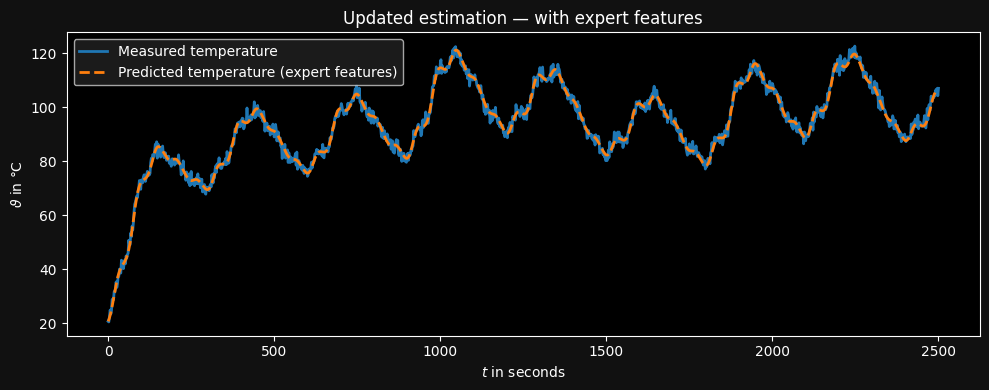

In [12]:
pred_expert = predict_DE_expert()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tsteps_NODE, y,           lw=2, label="Measured temperature")
ax.plot(tsteps_NODE, pred_expert, lw=2, linestyle='--',
        label="Predicted temperature (expert features)")
ax.set(title="Updated estimation — with expert features",
       xlabel=r"$t$ in seconds", ylabel=r"$\vartheta$ in °C")
ax.legend(loc="upper left", facecolor="#222222", labelcolor="white")
ax.set_facecolor("#000000"); fig.patch.set_facecolor("#111111")
for obj in [ax.title, ax.xaxis.label, ax.yaxis.label]: obj.set_color("white")
ax.tick_params(colors="white")
[s.set_edgecolor("white") for s in ax.spines.values()]
plt.tight_layout(); plt.show()


We can also compare the convergence of both variants side by side:

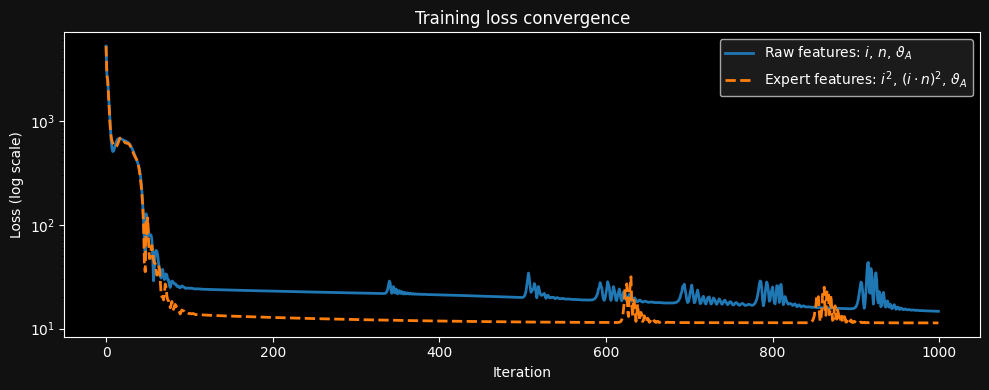

Training RMSE — raw features:    1.701 °C
Training RMSE — expert features: 1.496 °C


In [13]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(losses_raw,    lw=2, label=r"Raw features: $i,\,n,\,\vartheta_A$")
ax.semilogy(losses_expert, lw=2, label=r"Expert features: $i^2,\,(i\cdot n)^2,\,\vartheta_A$",
            linestyle='--')
ax.set(title="Training loss convergence", xlabel="Iteration", ylabel="Loss (log scale)")
ax.legend(loc="upper right", facecolor="#222222", labelcolor="white")
ax.set_facecolor("#000000"); fig.patch.set_facecolor("#111111")
for obj in [ax.title, ax.xaxis.label, ax.yaxis.label]: obj.set_color("white")
ax.tick_params(colors="white")
[s.set_edgecolor("white") for s in ax.spines.values()]
plt.tight_layout(); plt.show()

rmse_raw    = np.sqrt(np.mean((y - pred_raw   )**2))
rmse_expert = np.sqrt(np.mean((y - pred_expert)**2))
print(f"Training RMSE — raw features:    {rmse_raw:.3f} °C")
print(f"Training RMSE — expert features: {rmse_expert:.3f} °C")


With expert features the estimation accuracy is further improved and is on par with the NODE approach, which **highlights the importance of well-chosen features in data-driven modeling of dynamical systems**.

Comparing the black-box difference-equation model to the grey-box Hammerstein NODE:

- **Time-grid flexibility**: The NODE delivers a continuous-time ODE solvable on arbitrary grids. The discrete-time model is fixed to the sampling interval $\Delta t$ used during identification.
- **Structural pre-knowledge**: The black-box model can perform well with good feature engineering alone — but this is problem-specific and cannot be generalised to more complex systems.
- **Interpretability**: The NODE retains physical interpretability (e.g. inspectable power losses $P_\mathrm{v}$). The black-box model offers no such intermediate quantities.
